# Learning Detection Comparison (Strategies 1–3)

This notebook:
1) Runs Bayesian strategy analysis for multiple strategies (Figure 1-style)
2) Selects the dominant rule strategy automatically (go_left/go_right/go_cued)
3) Computes learning trial using:
   - Strategy 1: Sequence criterion
   - Strategy 2: Sequence + Precision
   - Strategy 3: Expert (posterior excludes chance)
4) Plots all learning trials on the rule-strategy MAP plot

In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

from Functions.standardize_dataset import standardize_dataset
from Functions.set_Beta_prior import set_priors
from Functions.update_strategy_posterior_probability import update_strategy_posterior_probability
from Functions.Summaries_of_Beta_distribution import summaries_of_Beta_Distribution
from Functions.plotSessionStructure import plotSessionStructure
from Functions.interpolate_null_trials import interpolate_null_trials
from scipy.stats import beta

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import strategymodels

# Load + standardize
from config import data_path, prior_type, decay_rate, save_output_csv, strategy_name
from Functions.standardize_dataset import standardize_dataset

TestData = pd.read_csv(data_path)
TestData = standardize_dataset(TestData)
no_Trials = len(TestData)

# We will detect learning per RULE BLOCK, not across the entire session,
# because the task rule changes multiple times.
# Therefore "until end" means: until the end of the current block.

In [2]:
strategies = [
    "go_left",
    "go_right",
    "go_cued",
    "win_stay_spatial",
    "lose_shift_cued",
    "lose_shift_spatial"
]

rule_strategies = ["go_left", "go_right", "go_cued"]

strategy_functions = {}
for s in strategies:
    try:
        strategy_functions[s] = getattr(strategymodels, s)
    except AttributeError:
        raise ValueError(f"Strategy '{s}' not found in strategymodels.")

In [3]:
alpha0, beta0 = set_priors(prior_type)

Output_collection = {}
event_totals = {}

for s in strategies:
    Output_collection[s] = pd.DataFrame(columns=[
        "Alpha", "Beta",
        "MAPprobability", "Precision",
        "Alpha_interpolated", "Beta_interpolated",
        "MAPprobability_interpolated", "Precision_interpolated"
    ])
    event_totals[s] = {"success_total": 0, "failure_total": 0}

In [4]:
for trial in range(len(TestData)):

    rows_of_data = TestData.iloc[0:trial+1]

    for s in strategies:

        trial_type = strategy_functions[s](rows_of_data)

        success_total, failure_total, Alpha, Beta = update_strategy_posterior_probability(
            trial_type,
            decay_rate,
            event_totals[s]["success_total"],
            event_totals[s]["failure_total"],
            alpha0,
            beta0
        )

        event_totals[s]["success_total"] = success_total
        event_totals[s]["failure_total"] = failure_total

        MAPprobability = summaries_of_Beta_Distribution(Alpha, Beta, "MAP")
        precision = summaries_of_Beta_Distribution(Alpha, Beta, "precision")

        this_trials_data = {
            "Alpha": Alpha,
            "Beta": Beta,
            "MAPprobability": MAPprobability,
            "Precision": precision
        }

        if trial > 0:
            previous_trials_data = Output_collection[s].iloc[trial-1]
        else:
            previous_trials_data = Output_collection[s]

        new_row_of_data = interpolate_null_trials(
            this_trials_data,
            previous_trials_data,
            alpha0,
            beta0
        )

        Output_collection[s] = pd.concat(
            [Output_collection[s], pd.DataFrame([new_row_of_data])],
            ignore_index=True
        )

/var/folders/1p/18jwl7x13xdgtw3zwr3q9zfr0000gn/T/ipykernel_8991/2211875573.py:43: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  Output_collection[s] = pd.concat(


In [5]:
# --- Get block boundaries (rule changes) ---
if "RuleChangeTrials" in TestData.columns:
    # e.g. per-trial vector; unique trial indices where rule changes
    block_boundaries = sorted(set(TestData["RuleChangeTrials"].dropna().astype(int).tolist()))
elif "NewSessionTrials" in TestData.columns:
    block_boundaries = sorted(set(TestData["NewSessionTrials"].dropna().astype(int).tolist()))
else:
    block_boundaries = []

# Remove 0 and out-of-range values if they exist
block_boundaries = [b for b in block_boundaries if 0 < b < len(TestData)]

In [6]:
final_MAPs = {s: Output_collection[s]["MAPprobability"].iloc[-1] for s in rule_strategies}
target_strategy = max(final_MAPs, key=final_MAPs.get)

print("Final MAPs (rule strategies):", final_MAPs)
print("Dominant rule strategy:", target_strategy)

Final MAPs (rule strategies): {'go_left': np.float64(0.999), 'go_right': np.float64(0.001), 'go_cued': np.float64(0.47100000000000003)}
Dominant rule strategy: go_left


In [7]:
rule_strategies = ["go_left", "go_right", "go_cued"]

final_MAPs = {s: Output_collection[s]["MAPprobability"].iloc[-1] for s in rule_strategies}
target_strategy = max(final_MAPs, key=final_MAPs.get)

# others = the OTHER rule strategies (needed for Strategy 2)
others = [s for s in rule_strategies if s != target_strategy]

In [ ]:
def learning_trial_sequence_per_block(MAP,
                                      block_boundaries,
                                      chance=0.5,
                                      min_trials=5):
    """
    Sequence criterion per block:
    For each rule block, find first trial t such that
    MAP[t:block_end] > chance for all remaining trials,
    with at least min_trials remaining.
    min_trials guards against spurious detections caused by a
    small number of trials at a session boundary happening to
    exceed chance.
    """

    MAP = np.asarray(MAP)

    starts = [0] + block_boundaries
    ends   = block_boundaries + [len(MAP)]

    learning_trials = []

    for start, end in zip(starts, ends):

        lt = None

        for t in range(start, end):
            remaining = MAP[t:end]
            if len(remaining) >= min_trials and np.all(remaining > chance):
                lt = t
                break

        learning_trials.append(lt)

    return learning_trials

In [ ]:
def learning_trial_sequence_precision_per_block(Output_collection,
                                                target,
                                                others,
                                                block_boundaries,
                                                chance=0.5,
                                                min_trials=5):
    """
    Strategy 2 per block:
    - MAP(target) stays > chance until block end, with at least min_trials remaining
    - AND Precision(target) at learning trial >= max Precision(others)
    """

    MAP_t  = Output_collection[target]["MAPprobability"].values
    PREC_t = Output_collection[target]["Precision"].values

    PREC_others = np.vstack([
        Output_collection[o]["Precision"].values for o in others
    ])

    max_other = PREC_others.max(axis=0)

    starts = [0] + block_boundaries
    ends   = block_boundaries + [len(MAP_t)]

    learning_trials = []

    for start, end in zip(starts, ends):

        lt = None

        for t in range(start, end):
            remaining = MAP_t[t:end]
            if (len(remaining) >= min_trials and
                np.all(remaining > chance) and
                PREC_t[t] >= max_other[t]):
                lt = t
                break

        learning_trials.append(lt)

    return learning_trials

In [10]:
from scipy.stats import beta

def learning_trial_expert_per_block(Output_collection,
                                    target,
                                    block_boundaries,
                                    chance=0.5,
                                    prob_thresh=0.95):
    """
    Strategy 3 per block:
    P(p > chance) >= prob_thresh for all trials t:block_end
    """

    A = Output_collection[target]["Alpha"].values
    B = Output_collection[target]["Beta"].values

    p_gt = 1.0 - beta.cdf(chance, A, B)

    starts = [0] + block_boundaries
    ends   = block_boundaries + [len(p_gt)]

    learning_trials = []

    for start, end in zip(starts, ends):

        lt = None

        for t in range(start, end):
            if np.all(p_gt[t:end] >= prob_thresh):
                lt = t
                break

        learning_trials.append(lt)

    return learning_trials

In [11]:
if "RuleChangeTrials" in TestData.columns:
    block_boundaries = sorted(
        set(TestData["RuleChangeTrials"].dropna().astype(int))
    )
else:
    block_boundaries = []

In [12]:
MAP = Output_collection[target_strategy]["MAPprobability"].values

t1_list = learning_trial_sequence_per_block(
    MAP,
    block_boundaries
)

t2_list = learning_trial_sequence_precision_per_block(
    Output_collection,
    target_strategy,
    others,
    block_boundaries
)

t3_list = learning_trial_expert_per_block(
    Output_collection,
    target_strategy,
    block_boundaries
)

/var/folders/1p/18jwl7x13xdgtw3zwr3q9zfr0000gn/T/ipykernel_8991/1270267499.py:64: UserWarning: Legend does not support handles for Text instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  handles, labels = plt.gca().get_legend_handles_labels()


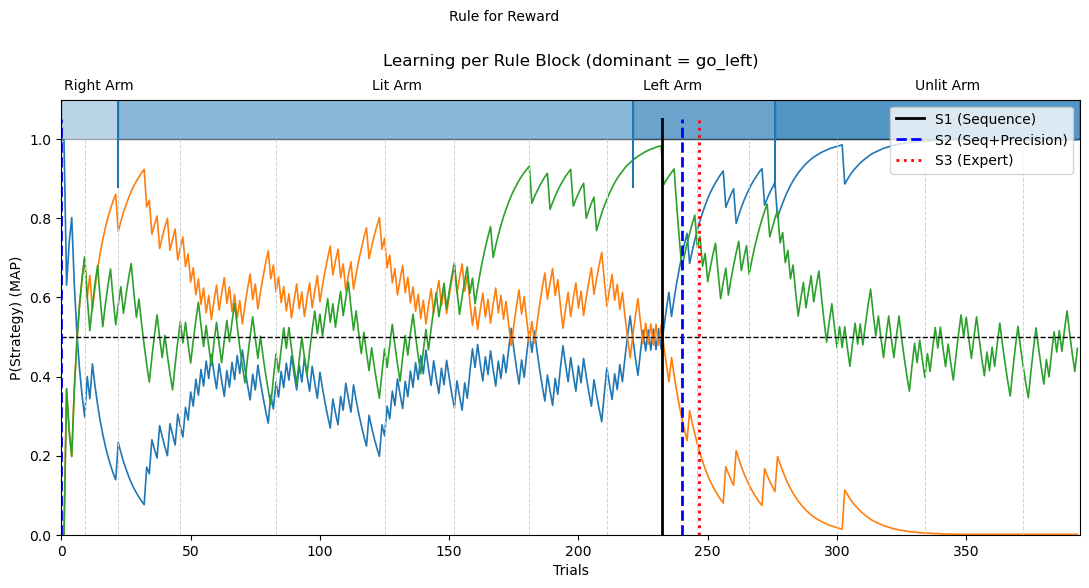

In [19]:
plt.figure(figsize=(11, 6))

# ---------------------------------------
# 1) Plot MAP curves
# ---------------------------------------
for s in rule_strategies:
    plt.plot(Output_collection[s]["MAPprobability"],
             linewidth=1.2,
             label=s)

plt.axhline(0.5,
            linestyle="--",
            linewidth=1.0,
            color="black",
            label="chance = 0.5")

# ---------------------------------------
# 2) Plot learning trials (offset to avoid overlap)
# ---------------------------------------

offset = 0.6  # small horizontal shift

offset = 0.6
ymax = 1.05

# Strategy 1
for lt in t1_list:
    if lt is not None:
        plt.plot([lt - offset, lt - offset], [0, ymax],
                 color="black", linewidth=2)

# Strategy 2
for lt in t2_list:
    if lt is not None:
        plt.plot([lt, lt], [0, ymax],
                 color="blue", linestyle="--", linewidth=2)

# Strategy 3
for lt in t3_list:
    if lt is not None:
        plt.plot([lt + offset, lt + offset], [0, ymax],
                 color="red", linestyle=":", linewidth=2)
# ---------------------------------------
# 3) Plot rule structure (top shading)
# ---------------------------------------
try:
    plotSessionStructure(TestData)
except Exception:
    pass

# ---------------------------------------
# 4) Formatting
# ---------------------------------------
plt.xlabel("Trials")
plt.ylabel("P(Strategy) (MAP)")
plt.title(
    f"Learning per Rule Block (dominant = {target_strategy})",
    pad=25
)
plt.xlim(0, len(TestData))
plt.ylim(0, 1.1)

# Remove duplicate legend entries
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
from matplotlib.lines import Line2D

custom_lines = [
    Line2D([0], [0], color="black", lw=2),
    Line2D([0], [0], color="blue", lw=2, linestyle="--"),
    Line2D([0], [0], color="red", lw=2, linestyle=":")
]

plt.legend(
    custom_lines,
    ["S1 (Sequence)", "S2 (Seq+Precision)", "S3 (Expert)"],
    loc="upper right"
)
plt.subplots_adjust(top=0.85)
plt.tight_layout()
plt.show()

In [14]:
df_results = pd.DataFrame({
    "Block": range(1, len(t1_list)+1),
    "Sequence (S1)": t1_list,
    "Seq+Precision (S2)": t2_list,
    "Expert (S3)": t3_list
})

df_results

,Block,Sequence (S1),Seq+Precision (S2),Expert (S3)
0,1,NaN,NaN,NaN
1,2,0.0,0.0,NaN
2,3,233.0,240.0,246.0
